### Building Chatbot With Multiple Tools Using Langgraph

#### Aim
Create a chatbot with tool capabilities from arxiv, wikipedia search and some functions

In [2]:
from langchain_community.tools import ArxivQueryRun,WikipediaQueryRun
from langchain_community.utilities import ArxivAPIWrapper,WikipediaAPIWrapper
import warnings

warnings.filterwarnings("ignore", category=DeprecationWarning)

In [3]:
api_wrapper_arxiv=ArxivAPIWrapper(top_k_results=2,doc_content_chars_max=500)
arxiv=ArxivQueryRun(api_wrapper=api_wrapper_arxiv)
print(arxiv)
print(arxiv.name)

api_wrapper=ArxivAPIWrapper(arxiv_search=<class 'arxiv.Search'>, arxiv_exceptions=(<class 'arxiv.ArxivError'>, <class 'arxiv.UnexpectedEmptyPageError'>, <class 'arxiv.HTTPError'>), top_k_results=2, ARXIV_MAX_QUERY_LENGTH=300, continue_on_failure=False, load_max_docs=100, load_all_available_meta=False, doc_content_chars_max=500)
arxiv


In [4]:
import arxiv as arxiv_module

# Ensure compatibility across arxiv package versions while avoiding recursion:
# Save original methods if present so our fallbacks call the originals (not any patched wrappers).
if hasattr(arxiv_module.Search, "results") and not hasattr(arxiv_module.Search, "__original_results__"):
    arxiv_module.Search.__original_results__ = arxiv_module.Search.results
if hasattr(arxiv_module.Search, "__iter__") and not hasattr(arxiv_module.Search, "__original_iter__"):
    arxiv_module.Search.__original_iter__ = arxiv_module.Search.__iter__

# If Search lacks __iter__ but has an original results, add a safe __iter__
if not hasattr(arxiv_module.Search, "__iter__") and hasattr(arxiv_module.Search, "__original_results__"):
    def __iter__(self):
        return iter(arxiv_module.Search.__original_results__(self))
    arxiv_module.Search.__iter__ = __iter__
# If Search lacks results but has an original __iter__, add a safe results
elif not hasattr(arxiv_module.Search, "results") and hasattr(arxiv_module.Search, "__original_iter__"):
    def results(self):
        return list(arxiv_module.Search.__original_iter__(self))
    arxiv_module.Search.results = results

print(arxiv.invoke("Attention iss all you need"))

Published: 2021-05-06
Title: Do You Even Need Attention? A Stack of Feed-Forward Layers Does Surprisingly Well on ImageNet
Authors: Luke Melas-Kyriazi
Summary: The strong performance of vision transformers on image classification and other vision tasks is often attributed to the design of their multi-head attention layers. However, the extent to which attention is responsible for this strong performance remains unclear. In this short report, we ask: is the attention layer even necessary? Specifi


In [5]:
api_wrapper_wiki=WikipediaAPIWrapper(top_k_results=1,doc_content_chars_max=500)
wiki=WikipediaQueryRun(api_wrapper=api_wrapper_wiki)
wiki.name

'wikipedia'

In [6]:
wiki.invoke("What is machine learning")

'Page: Machine learning\nSummary: Machine learning (ML) is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from  data and generalize to unseen data, and thus perform tasks without being explicitly programmed. Advances in the field of deep learning have allowed neural networks, a class of statistical algorithms, to surpass many previous machine learning approaches in performance.\nStatistics and mathematical optimisation m'

In [7]:
from dotenv import load_dotenv
load_dotenv()

import os

os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")



In [8]:
### Tavily Search Tool
from langchain_community.tools.tavily_search import TavilySearchResults

tavily = TavilySearchResults()

In [9]:
tavily.invoke("Provide me the recent AI news for July 4th 2026")

[{'title': 'Top 10 AI News: July 4 2026 Daily Roundup',
  'url': 'https://unrot.co/blogs/today-top-10-ai-news-july-4-2026',
  'content': "## AI News Today July 4 2026: Top 10 Stories\n\nHappy Independence Day to US readers. The AI industry celebrated by publishing some of the year's most sobering data all at once. Five governments jointly warned that AI cyberattacks are months, not years, away. The US added only 57,000 jobs in June, the weakest monthly number since 2024, with AI cited among the structural causes. Tesla is capping engineers' AI token spending at $200 per week after some burned thousands of dollars weekly. And Menlo Ventures just closed the largest fund in its 50-year history, with its Anthropic bet now reportedly worth nearly $14 billion.\n\nToday is Friday, July 4, 2026. Geneva AI Week starts in two days. Fable 5's billing structure changes in three days. Here are the 10 stories that matter. [...] The RAISE US coalition, a workforce development initiative backed by maj

In [10]:
### Combine all the tools in the list

tools=[arxiv,wiki,tavily]

In [11]:
## Initialize my LLM model

from langchain_groq import ChatGroq

llm=ChatGroq(model="openai/gpt-oss-120b")

llm_with_tools=llm.bind_tools(tools)

In [12]:
from pprint import pprint
from langchain_core.messages import AIMessage, HumanMessage
llm_with_tools.invoke([HumanMessage(content=f"What is the recent AI News")])

AIMessage(content='', additional_kwargs={'reasoning_content': 'The user asks: "What is the recent AI News". Likely wants a summary of recent AI news. Need up-to-date info as of now (2026-07-05). Should browse recent news via search. Use tavily_search_results_json for current events.', 'tool_calls': [{'id': 'fc_d40081d9-425b-4b8e-8cc0-04f77371a874', 'function': {'arguments': '{"query":"latest AI news July 2026"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 93, 'prompt_tokens': 291, 'total_tokens': 384, 'completion_time': 0.195456299, 'completion_tokens_details': {'reasoning_tokens': 56}, 'prompt_time': 0.01181983, 'prompt_tokens_details': None, 'queue_time': 0.280915706, 'total_time': 0.207276129}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_e5b4e54fbb', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f3333-42cc-7cc0-b102-7

In [13]:
llm_with_tools.invoke([HumanMessage(content=f"What is the recent AI News")]).tool_calls

[{'name': 'tavily_search_results_json',
  'args': {'query': 'latest AI news July 2026'},
  'id': 'fc_57036f9a-8338-4a32-a871-e8711f6ea6b9',
  'type': 'tool_call'}]

In [14]:
## State Schema
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from typing import Annotated
from langgraph.graph.message import add_messages
class State(TypedDict):
    messages:Annotated[list[AnyMessage],add_messages]

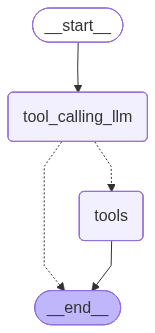

In [15]:
### Entire Chatbot With LangGraph
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

### Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

# Build graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition,
)
builder.add_edge("tools", END)


graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))


In [16]:
messages=graph.invoke({"messages":HumanMessage(content="1706.03762")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

1706.03762
================================== Ai Message ==================================
Tool Calls:
  arxiv (fc_c69e07b8-2219-4082-b19a-871d0a02be89)
 Call ID: fc_c69e07b8-2219-4082-b19a-871d0a02be89
  Args:
    query: 1706.03762
================================= Tool Message =================================
Name: arxiv

Published: 2023-08-02
Title: Attention Is All You Need
Authors: Ashish Vaswani, Noam Shazeer, Niki Parmar, Jakob Uszkoreit, Llion Jones, Aidan N. Gomez, Lukasz Kaiser, Illia Polosukhin
Summary: The dominant sequence transduction models are based on complex recurrent or convolutional neural networks in an encoder-decoder configuration. The best performing models also connect the encoder and decoder through an attention mechanism. We propose a new simple network architecture, the Transformer, base


In [18]:
messages=graph.invoke({"messages":HumanMessage(content="Provide me the top 10 recent AI news for July 4th  2026")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

Provide me the top 10 recent AI news for July 4th  2026
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (fc_5b3bcf91-db8c-4cd3-aeed-afc8d7a7fa21)
 Call ID: fc_5b3bcf91-db8c-4cd3-aeed-afc8d7a7fa21
  Args:
    query: July 4 2026 AI news
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "Top 10 AI News: July 4 2026 Daily Roundup - unrot.co", "url": "https://unrot.co/blogs/today-top-10-ai-news-july-4-2026", "content": "## AI News Today July 4 2026: Top 10 Stories\n\nHappy Independence Day to US readers. The AI industry celebrated by publishing some of the year's most sobering data all at once. Five governments jointly warned that AI cyberattacks are months, not years, away. The US added only 57,000 jobs in June, the weakest monthly number since 2024, with AI cit

In [19]:
messages=graph.invoke({"messages":HumanMessage(content="What is machine learning")})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

What is machine learning
================================== Ai Message ==================================

**Machine learning (ML)** is a sub‑field of artificial intelligence (AI) that focuses on developing algorithms and statistical models that enable computers to *learn* from data—i.e., to improve their performance on a specific task without being explicitly programmed for every possible situation.

---

## Core Idea

1. **Data → Model → Prediction**  
   - **Data** (examples, measurements, or observations) are fed into an algorithm.  
   - The algorithm **fits a model**—a mathematical representation of patterns in the data.  
   - Once trained, the model can **predict** or make decisions on new, unseen data.

2. **Learning Process**  
   - **Training**: Adjust model parameters (e.g., weights in a neural network) to minimize a loss (error) on the training data.  
   - **Evaluation/Validation**: Test the